# アニーリングを用いたクラスタリング

このチュートリアルでは、アニーリングの応用の一例としてOpenjijを利用したクラスタリングを取り上げます。  

## クラスタリング

クラスタリングとは与えられたデータを$n$個のクラスターに分けるというタスクです($n$は外部から与えられているとします)。簡単のため、今回はクラスター数が2を考えましょう。

### クラスタリングのハミルトニアン
今回は、以下のハミルトニアンを最小化することでクラスタリングを行います。

$$
H = - \sum_{i, j} \frac{1}{2}d_{i,j} (1 - \sigma _i \sigma_j)
$$

$i, j$はサンプルの番号、$d_{i,j}$は２つのサンプル間の距離、$\sigma_i=\{-1,1\}$は２つのクラスターのどちらかに属しているかを表すスピン変数です。  
このハミルトニアンの和の各項は   

- $\sigma_i  = \sigma_j $のとき、0
- $\sigma_i  \neq \sigma_j $のとき、$d_{i,j}$  

となります。右辺のマイナスに注意すると、ハミルトニアン全体では「異なるクラスに属しているサンプル同士の距離を最大にする$\{\sigma _1, \sigma _2 \ldots \}$の組を選びなさい」という問題に帰着することがわかります。

## JijModelingによる定式化

JijModelingを用いて、上述のハミルトニアンを定式化しましょう。
そのために必要となる変数を定義します。
JijModelingでは、スピン変数$\sigma_i$を扱えないため、バイナリ変数$x_i$で書けるように、$\sigma_i = 2x_i - 1$という関係を用いて書き直します。

In [1]:
import jijmodeling as jm

problem = jm.Problem("Clustering")

d = problem.Float("d", ndim=2)
N = problem.DependentVar("N", d.len_at(0))
x = problem.BinaryVar("x", shape=(N, ))

def sigma(i):
    return 2 * x[i] - 1


ここでは `d` をサンプル間の距離行列、`N` をサンプル数（`d` の次元から自動的に決定）、`x` をバイナリ変数として定義しています。また、スピン変数との対応 $\sigma_i = 2x_i - 1$ を `sigma` 関数として定義しています。

### ハミルトニアン

先ほどのハミルトニアンを定式化しましょう。

In [2]:
problem += -jm.sum(
    jm.product(N, N),
    lambda i, j: d[i, j] * (1 - (sigma(i) * sigma(j))),
)

定式化された数理モデルを、Jupyter Notebookで表示してみましょう。

In [3]:
problem

Problem(name="Clustering", sense=MINIMIZE, objective=- sum(set((N, N)).map(lambda ((i, j): Tuple[natural, natural]): d[i, j] * (1 - (2 * x[i] - 1) * (2 * x[j] - 1)))), constraints=[])

## インスタンスの作成

今回は人工的に二次元平面上の明らかに線形分離可能なデータを生成しましょう。

In [4]:
import numpy as np
import pandas as pd

from scipy.spatial import distance_matrix

data = []
label = []
for i in range(100):
    # [0, 1]の乱数を生成
    p = np.random.uniform(0, 1)
    # ある条件を満たすときをクラス1、満たさないときを-1
    cls =1 if p>0.5 else -1
    # ある座標を中心とする正規分布に従う乱数を作成
    data.append(np.random.normal(0, 0.5, 2) + np.array([cls, cls]))
    label.append(cls)
# DataFrameとして整形
df1 = pd.DataFrame(data, columns=["x", "y"], index=range(len(data)))
df1["label"] = label
instance_data = {'d': distance_matrix(df1, df1)}

生成されたデータを可視化してみます。

<Axes: xlabel='x', ylabel='y'>

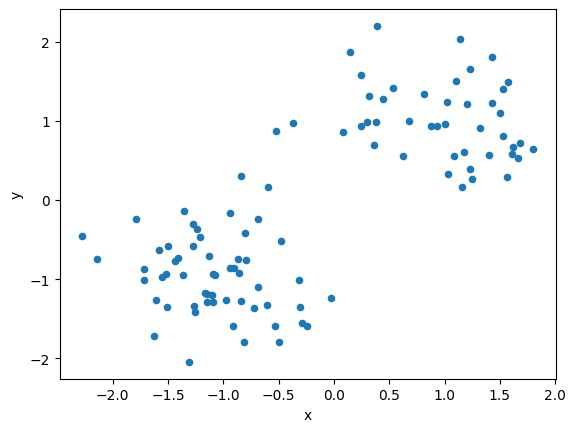

In [5]:
df1.plot(kind='scatter', x="x", y="y")

## OpenJijによる最適化計算の実行

OpenJijのシミュレーテッド・アニーリングを用いて、最適化問題を解いてみましょう。

In [6]:
from ommx_openjij_adapter import OMMXOpenJijSAAdapter

instance = problem.eval(instance_data)

adapter = OMMXOpenJijSAAdapter(instance)
best_sample = adapter.sample(
    instance, num_reads=100
).best_feasible_unrelaxed

## 解の可視化

最後に、得られた解を可視化しましょう。

Text(0, 0.5, 'y')

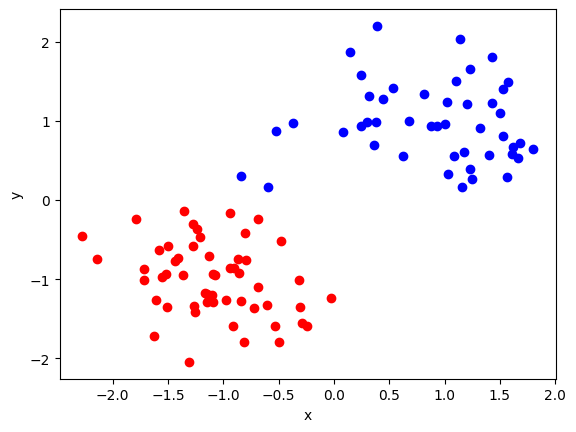

In [7]:
import matplotlib.pyplot as plt

df = best_sample.decision_variables_df
x_indices = set(row["subscripts"][0] for _, row in df.iterrows() if row["name"] == "x" and row["value"] > 0.5)
for idx in range(len(instance_data['d'])):
    color = "b" if idx in x_indices else "r"
    plt.scatter(df1.loc[idx]["x"], df1.loc[idx]["y"], color=color)
plt.xlabel('x')
plt.ylabel('y')

赤と青の2つのクラスに分類できていることがわかります。